# Check sync — Awinda ID alignment debug

Debug notebook for **sync lag** between model ID (from Awinda IK) and OpenSim ID.

**Baseline (process_awinda):** first ankle moment negative peak on model vs OpenSim ID.

**Validation (cells 5–6):** compare three sync methods side-by-side.

**Explorer (cell 9):** interactive xcorr-sync ID debugger (recommended method).

| Method | Signals | Reference |
|--------|---------|-----------|
| `ankle_moment_peak` | Model vs OpenSim ankle moment | current pipeline |
| `hip_angle_peak` | Awinda vs Vicon `hip_flexion_r` peak ≥ 15° | compare_jinwoo style |
| `angle_xcorr` | Awinda vs Vicon hip+knee angles (z-scored xcorr) | robust multi-joint |

All methods use `lag = awinda_or_pred_idx - vicon_or_id_idx`, clipped to ±30 s. Post-sync ID RMSE/R² uses optional 15 s trim.

Default focus: **AB01** trials (change `SUBJECT` / `CONDITION` in the config cell).

Use kernel `jinwoo-addbiomech` (needs PyTorch).

In [ ]:
import json
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import butter, sosfilt, sosfiltfilt, find_peaks

warnings.filterwarnings('ignore', message='.*NumPy.*')

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'VQF'
CHECKPOINT = PROJECT_ROOT / 'runs/0512_ik_id_all_zero_in_zero_out/best_model.pt'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Focus subject / optional single trial ---
SUBJECT = 'AB08_Seokhyun'
CONDITION = 'RA_0p8mps'  # None = all ready trials for SUBJECT; e.g. 'LG_0p8mps'

SUBJECT_MASS_KG = {
    'AB01_Jinwoo': 88.0, 'AB02_Oscar': 71.1, 'AB03_Ilseung': 84.4,
    'AB04_Changseob': 74.0, 'AB05_Maria': 55.0, 'AB06_Jimin': 82.6,
    'AB07_Amy': 51.3, 'AB08_Seokhyun': 71.9,
}

CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
ID_COLS = [f'{c}_moment' for c in CHANNELS]
DEFAULT_FS_HZ = 100.0
ALIGN_MAX_LAG_SEC = 30.0
ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG = 0.8
HIP_PEAK_THRESHOLD_DEG = 15.0
XCORR_SKIP_SEC = 5.0  # skip early transients before xcorr scoring
TRANSIENT_TRIM_SEC = 15.0  # post-sync trim for ID metrics (match visualize_awinda)
PREVIEW_FRAMES = 500  # first 5 s at 100 Hz
PEAK_PLOT_SEC = 40.0  # ankle peak debug window (s)

sys.path.insert(0, str(PROJECT_ROOT))
from dataset import IK_DOF_NAMES
from model import TCN

IK_CHANNEL_IDX = [IK_DOF_NAMES.index(c) for c in CHANNELS]
XCORR_CHANNEL_IDX = [CHANNELS.index(c) for c in ('hip_flexion_r', 'knee_angle_r', 'hip_flexion_l', 'knee_angle_l')]

print(f'Subject focus: {SUBJECT}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'Device: {DEVICE}')

Subject focus: AB02_Oscar
Checkpoint: /home/metamobility3/Jinwoo/os_kinetics/runs/0512_ik_id_all_zero_in_zero_out/best_model.pt
Device: cuda


In [9]:
def parse_opensim_table(path: Path) -> pd.DataFrame:
    with open(path) as f:
        header_end = next(i for i, line in enumerate(f) if line.strip().lower() == 'endheader')
    return pd.read_csv(path, sep=r'\s+', skiprows=header_end + 1).set_index('time')


def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * fs_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(order, cutoff_hz / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, x) if mode == 'zero_phase' else sosfilt(sos, x)


def lpf_mc(X, fs_hz, cutoff_hz, order, mode='zero_phase'):
    return np.column_stack([butter_lpf(X[:, c], fs_hz, cutoff_hz, order, mode) for c in range(X.shape[1])])


def filename_to_condition(stem: str) -> str:
    speed, cond = stem.split('_', 1)
    return f'{cond.upper()}_{speed}'


def condition_to_pkl_stem(condition: str) -> str:
    cond, speed = condition.split('_', 1)
    return f'{speed}_{cond.lower()}'


def resolve_trial_paths(subject: str, condition: str):
    pkl_stem = condition_to_pkl_stem(condition)
    ik_dir = IMU_IK_ROOT / subject / 'ik' / IMU_IK_METHOD
    if not ik_dir.exists():
        ik_dir = IMU_IK_ROOT / subject
    pkl_path = ik_dir / f'{pkl_stem}.pkl'
    id_path = PROCESSED_ROOT / subject / 'awinda' / 'id' / f'{condition}_id.sto'
    return {
        'subject': subject,
        'condition': condition,
        'pkl_path': pkl_path,
        'id_path': id_path,
        'mass_kg': SUBJECT_MASS_KG.get(subject, np.nan),
    }


def list_subject_trials(subject: str):
    rows = []
    ik_dir = IMU_IK_ROOT / subject / 'ik' / IMU_IK_METHOD
    if not ik_dir.exists():
        ik_dir = IMU_IK_ROOT / subject
    for pkl_path in sorted(ik_dir.glob('*.pkl')):
        cond = filename_to_condition(pkl_path.stem)
        id_path = PROCESSED_ROOT / subject / 'awinda' / 'id' / f'{cond}_id.sto'
        rows.append({
            'subject': subject,
            'condition': cond,
            'pkl_path': pkl_path,
            'id_path': id_path if id_path.exists() else None,
            'mass_kg': SUBJECT_MASS_KG.get(subject, np.nan),
            'ready': id_path.exists() and pkl_path.exists(),
        })
    return pd.DataFrame(rows)


def _first_moment_neg_peak_idx(sig, fs_hz, threshold_nmpkg, start_offset_s=0.25):
    """First negative peak with magnitude >= threshold_nmpkg (value <= -threshold)."""
    x = np.asarray(sig, dtype=np.float64).copy()
    valid = np.isfinite(x)
    if valid.sum() < 20:
        raise RuntimeError('Too few finite samples for peak detection')
    x[~valid] = float(np.nanmedian(x[valid]))
    start_idx = min(len(x) - 1, max(0, int(round(start_offset_s * fs_hz))))
    span = float(np.nanmax(x) - np.nanmin(x))
    peaks, _ = find_peaks(
        -x,
        prominence=max(0.05, 0.10 * span),
        distance=max(1, int(round(0.3 * fs_hz))),
    )
    peaks = peaks[(peaks >= start_idx) & (x[peaks] <= -threshold_nmpkg)]
    if len(peaks):
        return int(peaks[0])
    crossing = np.where(x[start_idx:] <= -threshold_nmpkg)[0]
    if len(crossing):
        return int(start_idx + crossing[0])
    raise RuntimeError('No ankle moment negative peak found')


def list_moment_neg_peaks(sig, fs_hz, threshold_nmpkg, start_offset_s=0.25):
    """Debug helper: all negative peaks passing the same detector rules."""
    x = np.asarray(sig, dtype=np.float64).copy()
    valid = np.isfinite(x)
    if valid.sum() < 20:
        return pd.DataFrame(columns=['peak_idx', 'time_s', 'value_nmpkg', 'used_for_sync'])
    x[~valid] = float(np.nanmedian(x[valid]))
    start_idx = min(len(x) - 1, max(0, int(round(start_offset_s * fs_hz))))
    span = float(np.nanmax(x) - np.nanmin(x))
    peaks, _ = find_peaks(
        -x,
        prominence=max(0.05, 0.10 * span),
        distance=max(1, int(round(0.3 * fs_hz))),
    )
    peaks = peaks[(peaks >= start_idx) & (x[peaks] <= -threshold_nmpkg)]
    used_idx = int(peaks[0]) if len(peaks) else np.nan
    rows = [
        {
            'peak_idx': int(p),
            'time_s': float(p / fs_hz),
            'value_nmpkg': float(x[p]),
            'used_for_sync': bool(p == used_idx) if len(peaks) else False,
        }
        for p in peaks
    ]
    if not rows:
        crossing = np.where(x[start_idx:] <= -threshold_nmpkg)[0]
        if len(crossing):
            p = int(start_idx + crossing[0])
            rows = [{
                'peak_idx': p,
                'time_s': float(p / fs_hz),
                'value_nmpkg': float(x[p]),
                'used_for_sync': True,
            }]
    return pd.DataFrame(rows)


def estimate_lag_from_moments(pred_moment, id_moment, fs_hz, max_lag_samples, threshold_nmpkg=0.8):
    pred_idx = _first_moment_neg_peak_idx(pred_moment, fs_hz, threshold_nmpkg)
    id_idx = _first_moment_neg_peak_idx(id_moment, fs_hz, threshold_nmpkg)
    lag = int(pred_idx - id_idx)
    clipped = False
    if lag > max_lag_samples:
        lag, clipped = max_lag_samples, True
    elif lag < -max_lag_samples:
        lag, clipped = -max_lag_samples, True
    return lag, {'pred_peak_idx': pred_idx, 'id_peak_idx': id_idx, 'lag_clipped': clipped}


def clip_lag(lag, max_lag_samples):
    clipped = False
    if lag > max_lag_samples:
        lag, clipped = max_lag_samples, True
    elif lag < -max_lag_samples:
        lag, clipped = -max_lag_samples, True
    return int(lag), clipped


def build_awinda_ik_rad(imu_dict: dict) -> np.ndarray:
    return np.deg2rad(build_model_input_from_pkl(imu_dict))


def build_vicon_ik_rad(ik_df: pd.DataFrame) -> np.ndarray:
    pos_deg = np.full((len(ik_df), len(IK_DOF_NAMES)), np.nan)
    for j, name in enumerate(IK_DOF_NAMES):
        if name in ik_df.columns:
            pos_deg[:, j] = ik_df[name].to_numpy(dtype=np.float64)
    return np.deg2rad(pos_deg)


def _first_peak_index_above_threshold(sig, fs_hz, threshold_rad, start_offset_s=0.25):
    x = np.asarray(sig, dtype=np.float64).copy()
    valid = np.isfinite(x)
    if valid.sum() < 20:
        raise RuntimeError('Too few finite samples for peak detection')
    x[~valid] = float(np.nanmedian(x[valid]))
    start_idx = min(len(x) - 1, max(0, int(round(start_offset_s * fs_hz))))
    span = float(np.nanmax(x) - np.nanmin(x))
    peaks, _ = find_peaks(x, prominence=max(np.deg2rad(3.0), 0.10 * span), distance=max(1, int(round(0.3 * fs_hz))))
    peaks = peaks[(peaks >= start_idx) & (x[peaks] >= threshold_rad)]
    if len(peaks):
        return int(peaks[0]), 'peaks_above_threshold'
    crossing = np.where(x[start_idx:] >= threshold_rad)[0]
    if len(crossing):
        return int(start_idx + crossing[0]), 'threshold_crossing_fallback'
    raise RuntimeError('No peak above threshold found')


def estimate_lag_from_hip_peak(awinda_rad, vicon_rad, fs_hz, max_lag_samples, threshold_deg=15.0):
    hip_idx = IK_DOF_NAMES.index('hip_flexion_r')
    thr = np.deg2rad(float(threshold_deg))
    awinda_idx, awinda_method = _first_peak_index_above_threshold(awinda_rad[:, hip_idx], fs_hz, thr)
    vicon_idx, vicon_method = _first_peak_index_above_threshold(vicon_rad[:, hip_idx], fs_hz, thr)
    lag, clipped = clip_lag(int(awinda_idx - vicon_idx), max_lag_samples)
    return lag, {
        'awinda_peak_idx': awinda_idx,
        'vicon_peak_idx': vicon_idx,
        'awinda_peak_method': awinda_method,
        'vicon_peak_method': vicon_method,
        'lag_clipped': clipped,
    }


def _zscore_1d(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.isfinite(x)
    if m.sum() < 2:
        return np.zeros_like(x)
    mu, sd = float(np.nanmean(x[m])), float(np.nanstd(x[m]))
    if sd < 1e-9:
        return np.zeros_like(x)
    out = (x - mu) / sd
    out[~m] = 0.0
    return out


def estimate_lag_from_angle_xcorr(
    awinda_rad, vicon_rad, fs_hz, max_lag_samples,
    channel_idx=None, skip_s=5.0,
):
    """Multi-channel z-scored cross-correlation. lag = awinda_idx - vicon_idx."""
    channel_idx = list(channel_idx or XCORR_CHANNEL_IDX)
    awinda_6 = awinda_rad[:, IK_CHANNEL_IDX]
    vicon_6 = vicon_rad[:, IK_CHANNEL_IDX]
    awinda_f = lpf_mc(awinda_6, fs_hz, ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
    vicon_f = lpf_mc(vicon_6, fs_hz, ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)

    n = min(len(awinda_f), len(vicon_f))
    skip = int(round(skip_s * fs_hz))
    best_lag, best_score = 0, -np.inf
    for lag in range(-max_lag_samples, max_lag_samples + 1):
        start_a, start_b = max(lag, 0), max(-lag, 0)
        nn = min(len(awinda_f) - start_a, len(vicon_f) - start_b) - skip
        if nn < int(round(2.0 * fs_hz)):
            continue
        seg_a = awinda_f[start_a + skip:start_a + skip + nn]
        seg_b = vicon_f[start_b + skip:start_b + skip + nn]
        score = sum(float(np.dot(_zscore_1d(seg_a[:, c]), _zscore_1d(seg_b[:, c])) / nn) for c in channel_idx)
        if score > best_score:
            best_score, best_lag = score, lag
    lag, clipped = clip_lag(best_lag, max_lag_samples)
    return lag, {'xcorr_score': float(best_score), 'lag_clipped': clipped}


def eval_id_at_lag(pred_full, id_full, lag, fs_hz, trim_sec=0.0, min_samples=None):
    """Apply lag to model vs OpenSim ID; return mean RMSE/R² over 6 channels."""
    min_samples = min_samples or WINDOW_SIZE
    start_pred, start_id = max(lag, 0), max(-lag, 0)
    n_sync = min(len(pred_full) - start_pred, len(id_full) - start_id)
    trim_n = int(round(trim_sec * fs_hz))
    if n_sync - trim_n < min_samples:
        return np.nan, np.nan, 0
    pred = pred_full[start_pred + trim_n:start_pred + n_sync]
    idv = id_full[start_id + trim_n:start_id + n_sync]
    mean_rmse = float(np.nanmean([rmse_r2(pred[:, c], idv[:, c])[0] for c in range(6)]))
    mean_r2 = float(np.nanmean([rmse_r2(pred[:, c], idv[:, c])[1] for c in range(6)]))
    return mean_rmse, mean_r2, n_sync - trim_n


def build_model_input_from_pkl(imu_dict: dict) -> np.ndarray:
    n = len(next(iter(imu_dict.values())))
    pos_deg = np.zeros((n, len(IK_DOF_NAMES)), dtype=np.float64)
    key_map = {
        'hip_flexion_r': 'hip_flexion_r', 'knee_angle_r': 'knee_flexion_r', 'ankle_angle_r': 'ankle_flexion_r',
        'hip_flexion_l': 'hip_flexion_l', 'knee_angle_l': 'knee_flexion_l', 'ankle_angle_l': 'ankle_flexion_l',
    }
    sign_map = {'knee_angle_r': -1.0, 'knee_angle_l': -1.0}
    for ik_name, pkl_name in key_map.items():
        idx = IK_DOF_NAMES.index(ik_name)
        pos_deg[:, idx] = sign_map.get(ik_name, 1.0) * np.asarray(imu_dict[pkl_name], dtype=np.float64)
    return pos_deg


def rmse_r2(y_pred, y_true):
    m = np.isfinite(y_pred) & np.isfinite(y_true)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_true[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    r2 = float(np.corrcoef(y_pred[m], y_true[m])[0, 1] ** 2)
    return rmse, r2

print('Helpers ready.')

Helpers ready.


In [10]:
ckpt = torch.load(str(CHECKPOINT), map_location=DEVICE, weights_only=False)
with open(CHECKPOINT.parent / 'config.json') as f:
    train_cfg = json.load(f)

cfg = ckpt['model_config']
model = TCN(**{k: cfg[k] for k in ['n_input_channels', 'n_output_channels', 'hidden_channels', 'n_blocks', 'kernel_size', 'dropout']})
model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE).eval()

WINDOW_SIZE = int(ckpt.get('window_size', 100))
INPUT_INDICES = list(ckpt.get('input_indices', [6, 9, 10, 13, 16, 17]))
H = len(INPUT_INDICES) // 2
INPUT_IDX_R, INPUT_IDX_L = INPUT_INDICES[:H], INPUT_INDICES[H:]

ANGLE_CUTOFF = float(train_cfg.get('lowpass_cutoff_hz', 6.0))
VEL_CUTOFF = float(train_cfg.get('velocity_lowpass_cutoff_hz', 15.0))
OUT_CUTOFF = float(train_cfg.get('lowpass_cutoff_hz', 6.0))
FILTER_ORDER = int(train_cfg.get('lowpass_order', 4))
IN_MODE = str(train_cfg.get('input_lowpass_mode', 'zero_phase'))
OUT_MODE = str(train_cfg.get('output_lowpass_mode', 'zero_phase'))

@torch.no_grad()
def infer_one_side(pos_3, vel_3):
    x = np.concatenate([pos_3, vel_3], axis=1).astype(np.float32)
    n, W, c_out = x.shape[0], WINDOW_SIZE, cfg['n_output_channels']
    pred = np.zeros((n, c_out), dtype=np.float64)
    def _fwd(start):
        xt = torch.from_numpy(np.ascontiguousarray(x[start:start + W].T)).unsqueeze(0).to(DEVICE)
        return model(xt).squeeze(0).detach().cpu().numpy().T
    pred[:W] = _fwd(0)
    for start in range(1, n - W + 1):
        pred[start + W - 1] = _fwd(start)[W - 1]
    return pred.astype(np.float32)


def run_bilateral_inference(pos_full, vel_full):
    pr = infer_one_side(pos_full[:, INPUT_IDX_R], vel_full[:, INPUT_IDX_R])
    pl = infer_one_side(pos_full[:, INPUT_IDX_L], vel_full[:, INPUT_IDX_L])
    return np.concatenate([pr, pl], axis=1)

print(f'window={WINDOW_SIZE}, filters: angle={ANGLE_CUTOFF}Hz/{IN_MODE}, vel={VEL_CUTOFF}Hz/{IN_MODE}, out={OUT_CUTOFF}Hz/{OUT_MODE}')

window=100, filters: angle=6.0Hz/zero_phase, vel=15.0Hz/zero_phase, out=6.0Hz/zero_phase


In [11]:
manifest = list_subject_trials(SUBJECT)
if CONDITION is not None:
    manifest = manifest[manifest['condition'] == CONDITION]
ready = manifest[manifest['ready']].copy()
print(f'{SUBJECT}: {len(ready)} ready trials')
display(ready[['condition', 'mass_kg']])

ANKLE_MOMENT_IDX = CHANNELS.index('ankle_angle_r')
SYNC_DATA = {}
summary_rows = []

for _, row in ready.iterrows():
    subject, cond = row['subject'], row['condition']
    trial_key = f'{subject}::{cond}'
    try:
        imu = pickle.load(open(row['pkl_path'], 'rb'))
        pos_rad = np.deg2rad(build_model_input_from_pkl(imu))
        id_df = parse_opensim_table(row['id_path'])
        t_id = id_df.index.to_numpy(dtype=np.float64)
        fs_hz = 1.0 / float(np.median(np.diff(t_id))) if len(t_id) > 2 else DEFAULT_FS_HZ

        pos_f = lpf_mc(pos_rad, fs_hz, ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
        vel_f = lpf_mc(np.gradient(pos_f, 1.0 / fs_hz, axis=0), fs_hz, VEL_CUTOFF, FILTER_ORDER, IN_MODE)
        pred_nmpkg_full = run_bilateral_inference(pos_f, vel_f)
        pred_nmpkg_full_f = lpf_mc(pred_nmpkg_full, fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)

        id_nm = np.column_stack([
            id_df[c].to_numpy(dtype=np.float64) if c in id_df.columns else np.full(len(t_id), np.nan)
            for c in ID_COLS
        ])
        id_nmpkg_full_f = lpf_mc(id_nm / row['mass_kg'], fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)

        pred_ankle = pred_nmpkg_full_f[:, ANKLE_MOMENT_IDX]
        id_ankle = id_nmpkg_full_f[:, ANKLE_MOMENT_IDX]
        max_lag = int(round(ALIGN_MAX_LAG_SEC * fs_hz))
        lag, peak_info = estimate_lag_from_moments(
            pred_ankle, id_ankle, fs_hz, max_lag, ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG,
        )

        start_pred, start_id = max(lag, 0), max(-lag, 0)
        n_sync = min(len(pred_nmpkg_full_f) - start_pred, len(id_nmpkg_full_f) - start_id)
        if n_sync < WINDOW_SIZE:
            raise RuntimeError(f'Synced window too short: {n_sync}')

        pred_sync = pred_nmpkg_full_f[start_pred:start_pred + n_sync]
        id_sync = id_nmpkg_full_f[start_id:start_id + n_sync]
        mean_rmse = float(np.nanmean([rmse_r2(pred_sync[:, c], id_sync[:, c])[0] for c in range(6)]))
        mean_r2 = float(np.nanmean([rmse_r2(pred_sync[:, c], id_sync[:, c])[1] for c in range(6)]))

        pred_peaks_df = list_moment_neg_peaks(pred_ankle, fs_hz, ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG)
        id_peaks_df = list_moment_neg_peaks(id_ankle, fs_hz, ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG)

        SYNC_DATA[trial_key] = {
            'subject': subject,
            'condition': cond,
            'fs_hz': fs_hz,
            't_id': t_id,
            't_imu': np.arange(len(pred_nmpkg_full_f)) / fs_hz,
            'pred_full': pred_nmpkg_full_f,
            'id_full': id_nmpkg_full_f,
            'pred_ankle_full': pred_ankle,
            'id_ankle_full': id_ankle,
            'pred_sync': pred_sync,
            'id_sync': id_sync,
            'pred_peaks_df': pred_peaks_df,
            'id_peaks_df': id_peaks_df,
            'lag': lag,
            'start_pred': start_pred,
            'start_id': start_id,
            'n_sync': n_sync,
            'mean_rmse': mean_rmse,
            'mean_r2': mean_r2,
            **peak_info,
        }
        summary_rows.append({
            'trial': trial_key,
            'condition': cond,
            'n_imu': len(pred_nmpkg_full_f),
            'n_id': len(id_nmpkg_full_f),
            'n_sync': n_sync,
            'lag_samples': lag,
            'lag_seconds': lag / fs_hz,
            'lag_clipped': peak_info['lag_clipped'],
            'pred_peak_idx': peak_info['pred_peak_idx'],
            'id_peak_idx': peak_info['id_peak_idx'],
            'pred_peak_s': peak_info['pred_peak_idx'] / fs_hz,
            'id_peak_s': peak_info['id_peak_idx'] / fs_hz,
            'n_pred_peaks': len(pred_peaks_df),
            'n_id_peaks': len(id_peaks_df),
            'mean_rmse': mean_rmse,
            'mean_r2': mean_r2,
        })
        print(
            f'OK  {trial_key} | lag={lag:+d} ({lag / fs_hz:+.2f}s) clipped={peak_info["lag_clipped"]} | '
            f'peaks pred/id={len(pred_peaks_df)}/{len(id_peaks_df)} | RMSE={mean_rmse:.3f} R²={mean_r2:.3f}'
        )
    except Exception as exc:
        print(f'FAIL {trial_key}: {exc}')

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    display(summary_df.sort_values('condition'))

AB02_Oscar: 5 ready trials


,condition,mass_kg
0,LG_0p8mps,71.1
1,RA_0p8mps,71.1
2,RD_0p8mps,71.1
3,LG_1p2mps,71.1
4,LG_1p6mps,71.1


OK  AB02_Oscar::LG_0p8mps | lag=+1240 (+12.40s) clipped=False | peaks pred/id=58/57 | RMSE=0.325 R²=0.451
OK  AB02_Oscar::RA_0p8mps | lag=+407 (+4.07s) clipped=False | peaks pred/id=53/54 | RMSE=0.617 R²=0.070
OK  AB02_Oscar::RD_0p8mps | lag=+992 (+9.92s) clipped=False | peaks pred/id=70/129 | RMSE=0.591 R²=0.091
OK  AB02_Oscar::LG_1p2mps | lag=+411 (+4.11s) clipped=False | peaks pred/id=71/71 | RMSE=0.536 R²=0.163
OK  AB02_Oscar::LG_1p6mps | lag=+377 (+3.77s) clipped=False | peaks pred/id=79/98 | RMSE=0.785 R²=0.086


,trial,condition,n_imu,n_id,n_sync,lag_samples,lag_seconds,lag_clipped,pred_peak_idx,id_peak_idx,pred_peak_s,id_peak_s,n_pred_peaks,n_id_peaks,mean_rmse,mean_r2
0,AB02_Oscar::LG_0p8mps,LG_0p8mps,9917,8000,8000,1240,12.40,False,1401,161,14.01,1.61,58,57,0.324567,0.451425
3,AB02_Oscar::LG_1p2mps,LG_1p2mps,8388,8000,7977,411,4.11,False,457,46,4.57,0.46,71,71,0.536456,0.163408
4,AB02_Oscar::LG_1p6mps,LG_1p6mps,8419,8000,8000,377,3.77,False,402,25,4.02,0.25,79,98,0.785251,0.086243
1,AB02_Oscar::RA_0p8mps,RA_0p8mps,8879,8000,8000,407,4.07,False,475,68,4.75,0.68,53,54,0.616573,0.070209
2,AB02_Oscar::RD_0p8mps,RD_0p8mps,9264,8000,8000,992,9.92,False,1025,33,10.25,0.33,70,129,0.590682,0.090987


In [12]:
# --- Sync method comparison: ankle moment peak vs hip peak vs angle xcorr ---
if not SYNC_DATA:
    raise RuntimeError('Run cell 4 first.')

SYNC_METHODS = ['ankle_moment_peak', 'hip_angle_peak', 'angle_xcorr']
compare_rows = []

for trial_key, d in sorted(SYNC_DATA.items()):
    row = ready[ready['condition'] == d['condition']].iloc[0]
    fs_hz = d['fs_hz']
    max_lag = int(round(ALIGN_MAX_LAG_SEC * fs_hz))
    pred_full, id_full = d['pred_full'], d['id_full']

    vicon_path = PROCESSED_ROOT / d['subject'] / 'awinda' / 'ik' / f"{d['condition']}_ik.mot"
    if not vicon_path.exists():
        print(f'SKIP {trial_key}: missing Vicon IK {vicon_path.name}')
        continue

    imu = pickle.load(open(row['pkl_path'], 'rb'))
    awinda_rad = build_awinda_ik_rad(imu)
    vicon_rad = build_vicon_ik_rad(parse_opensim_table(vicon_path))

    method_lags = {
        'ankle_moment_peak': (d['lag'], {'lag_clipped': d['lag_clipped']}),
    }
    try:
        lag, info = estimate_lag_from_hip_peak(
            awinda_rad, vicon_rad, fs_hz, max_lag, HIP_PEAK_THRESHOLD_DEG,
        )
        method_lags['hip_angle_peak'] = (lag, info)
    except Exception as exc:
        method_lags['hip_angle_peak'] = (np.nan, {'error': str(exc)})
    try:
        lag, info = estimate_lag_from_angle_xcorr(
            awinda_rad, vicon_rad, fs_hz, max_lag, skip_s=XCORR_SKIP_SEC,
        )
        method_lags['angle_xcorr'] = (lag, info)
    except Exception as exc:
        method_lags['angle_xcorr'] = (np.nan, {'error': str(exc)})

    for method in SYNC_METHODS:
        lag, info = method_lags[method]
        if not np.isfinite(lag):
            compare_rows.append({
                'trial': trial_key, 'condition': d['condition'], 'method': method,
                'lag_samples': np.nan, 'lag_seconds': np.nan, 'lag_clipped': np.nan,
                'mean_rmse_raw': np.nan, 'mean_r2_raw': np.nan,
                'mean_rmse_trim': np.nan, 'mean_r2_trim': np.nan,
                'error': info.get('error', 'lag failed'),
            })
            continue
        rmse_raw, r2_raw, n_raw = eval_id_at_lag(pred_full, id_full, int(lag), fs_hz, trim_sec=0.0)
        rmse_trim, r2_trim, n_trim = eval_id_at_lag(
            pred_full, id_full, int(lag), fs_hz, trim_sec=TRANSIENT_TRIM_SEC,
        )
        compare_rows.append({
            'trial': trial_key,
            'condition': d['condition'],
            'method': method,
            'lag_samples': int(lag),
            'lag_seconds': float(lag / fs_hz),
            'lag_clipped': bool(info.get('lag_clipped', False)),
            'xcorr_score': float(info['xcorr_score']) if method == 'angle_xcorr' and 'xcorr_score' in info else np.nan,
            'mean_rmse_raw': rmse_raw,
            'mean_r2_raw': r2_raw,
            'mean_rmse_trim': rmse_trim,
            'mean_r2_trim': r2_trim,
            'n_eval_trim': n_trim,
            'error': None,
        })

compare_df = pd.DataFrame(compare_rows)
print(f'Sync method comparison ({SUBJECT}, {TRANSIENT_TRIM_SEC:.0f}s post-sync trim for trim columns)\n')

# Build xcorr-synced views for interactive explorer (cell 8)
XCORR_SYNC_DATA = {}
for trial_key, d in sorted(SYNC_DATA.items()):
    sub = compare_df[(compare_df['trial'] == trial_key) & (compare_df['method'] == 'angle_xcorr')]
    if sub.empty or not np.isfinite(sub.iloc[0]['lag_samples']):
        continue
    lag = int(sub.iloc[0]['lag_samples'])
    start_pred, start_id = max(lag, 0), max(-lag, 0)
    n_sync = min(len(d['pred_full']) - start_pred, len(d['id_full']) - start_id)
    trim_n = int(round(TRANSIENT_TRIM_SEC * d['fs_hz']))
    row = ready[ready['condition'] == d['condition']].iloc[0]
    vicon_path = PROCESSED_ROOT / d['subject'] / 'awinda' / 'ik' / f"{d['condition']}_ik.mot"
    imu = pickle.load(open(row['pkl_path'], 'rb'))
    awinda_6 = lpf_mc(build_awinda_ik_rad(imu)[:, IK_CHANNEL_IDX], d['fs_hz'], ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
    vicon_6 = lpf_mc(build_vicon_ik_rad(parse_opensim_table(vicon_path))[:, IK_CHANNEL_IDX], d['fs_hz'], ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
    rmse_trim, r2_trim, n_trim = eval_id_at_lag(
        d['pred_full'], d['id_full'], lag, d['fs_hz'], trim_sec=TRANSIENT_TRIM_SEC,
    )
    XCORR_SYNC_DATA[trial_key] = {
        **d,
        'lag': lag,
        'lag_clipped': bool(sub.iloc[0]['lag_clipped']),
        'xcorr_score': float(sub.iloc[0]['xcorr_score']),
        'start_pred': start_pred,
        'start_id': start_id,
        'n_sync': n_sync,
        'trim_n': trim_n,
        'pred_sync': d['pred_full'][start_pred:start_pred + n_sync],
        'id_sync': d['id_full'][start_id:start_id + n_sync],
        'awinda_hip_deg': np.rad2deg(awinda_6[:, 0]),
        'vicon_hip_deg': np.rad2deg(vicon_6[:, 0]),
        'mean_rmse_trim': rmse_trim,
        'mean_r2_trim': r2_trim,
        'n_eval_trim': n_trim,
    }

xcorr_summary_df = compare_df[compare_df['method'] == 'angle_xcorr'].copy()
print(f'Built XCORR_SYNC_DATA for {len(XCORR_SYNC_DATA)} trials')

pivot_lag = compare_df.pivot(index='condition', columns='method', values='lag_seconds')
pivot_r2 = compare_df.pivot(index='condition', columns='method', values='mean_r2_trim')
pivot_rmse = compare_df.pivot(index='condition', columns='method', values='mean_rmse_trim')

display(pivot_lag.rename(columns=lambda c: f'lag_s__{c}'))
display(pivot_r2.rename(columns=lambda c: f'R2_trim__{c}'))
display(pivot_rmse.rename(columns=lambda c: f'RMSE_trim__{c}'))

print('\nPer-trial detail:')
display(compare_df.sort_values(['condition', 'method']))

best_by_trial = (
    compare_df.dropna(subset=['mean_r2_trim'])
    .sort_values('mean_r2_trim', ascending=False)
    .groupby('trial', as_index=False)
    .first()[['trial', 'method', 'lag_seconds', 'mean_r2_trim', 'mean_rmse_trim']]
)
print('\nBest method per trial (by trimmed mean R²):')
display(best_by_trial)

Sync method comparison (AB02_Oscar, 15s post-sync trim for trim columns)

Built XCORR_SYNC_DATA for 5 trials


method,lag_s__angle_xcorr,lag_s__ankle_moment_peak,lag_s__hip_angle_peak
condition,,,
LG_0p8mps,12.40,12.40,12.43
LG_1p2mps,2.88,4.11,2.91
LG_1p6mps,2.59,3.77,2.60
RA_0p8mps,2.95,4.07,3.00
RD_0p8mps,7.59,9.92,7.60


method,R2_trim__angle_xcorr,R2_trim__ankle_moment_peak,R2_trim__hip_angle_peak
condition,,,
LG_0p8mps,0.445211,0.445211,0.407905
LG_1p2mps,0.664234,0.172182,0.550486
LG_1p6mps,0.742363,0.082037,0.709610
RA_0p8mps,0.683135,0.071961,0.490509
RD_0p8mps,0.624755,0.101493,0.601575


method,RMSE_trim__angle_xcorr,RMSE_trim__ankle_moment_peak,RMSE_trim__hip_angle_peak
condition,,,
LG_0p8mps,0.323243,0.323243,0.338448
LG_1p2mps,0.303085,0.533342,0.355442
LG_1p6mps,0.324740,0.789587,0.341918
RA_0p8mps,0.277998,0.609283,0.358315
RD_0p8mps,0.363305,0.588845,0.368919



Per-trial detail:


,trial,condition,method,lag_samples,lag_seconds,lag_clipped,xcorr_score,mean_rmse_raw,mean_r2_raw,mean_rmse_trim,mean_r2_trim,n_eval_trim,error
2,AB02_Oscar::LG_0p8mps,LG_0p8mps,angle_xcorr,1240,12.40,False,3.875302,0.324567,0.451425,0.323243,0.445211,6500,None
0,AB02_Oscar::LG_0p8mps,LG_0p8mps,ankle_moment_peak,1240,12.40,False,NaN,0.324567,0.451425,0.323243,0.445211,6500,None
1,AB02_Oscar::LG_0p8mps,LG_0p8mps,hip_angle_peak,1243,12.43,False,NaN,0.339341,0.413136,0.338448,0.407905,6500,None
5,AB02_Oscar::LG_1p2mps,LG_1p2mps,angle_xcorr,288,2.88,False,3.945388,0.307497,0.660463,0.303085,0.664234,6500,None
3,AB02_Oscar::LG_1p2mps,LG_1p2mps,ankle_moment_peak,411,4.11,False,NaN,0.536456,0.163408,0.533342,0.172182,6477,None
4,AB02_Oscar::LG_1p2mps,LG_1p2mps,hip_angle_peak,291,2.91,False,NaN,0.356620,0.548479,0.355442,0.550486,6500,None
8,AB02_Oscar::LG_1p6mps,LG_1p6mps,angle_xcorr,259,2.59,False,3.961672,0.327267,0.738932,0.324740,0.742363,6500,None
6,AB02_Oscar::LG_1p6mps,LG_1p6mps,ankle_moment_peak,377,3.77,False,NaN,0.785251,0.086243,0.789587,0.082037,6500,None
7,AB02_Oscar::LG_1p6mps,LG_1p6mps,hip_angle_peak,260,2.60,False,NaN,0.343959,0.706321,0.341918,0.709610,6500,None
11,AB02_Oscar::RA_0p8mps,RA_0p8mps,angle_xcorr,295,2.95,False,3.920502,0.279859,0.683470,0.277998,0.683135,6500,None



Best method per trial (by trimmed mean R²):


,trial,method,lag_seconds,mean_r2_trim,mean_rmse_trim
0,AB02_Oscar::LG_0p8mps,ankle_moment_peak,12.40,0.445211,0.323243
1,AB02_Oscar::LG_1p2mps,angle_xcorr,2.88,0.664234,0.303085
2,AB02_Oscar::LG_1p6mps,angle_xcorr,2.59,0.742363,0.324740
3,AB02_Oscar::RA_0p8mps,angle_xcorr,2.95,0.683135,0.277998
4,AB02_Oscar::RD_0p8mps,angle_xcorr,7.59,0.624755,0.363305


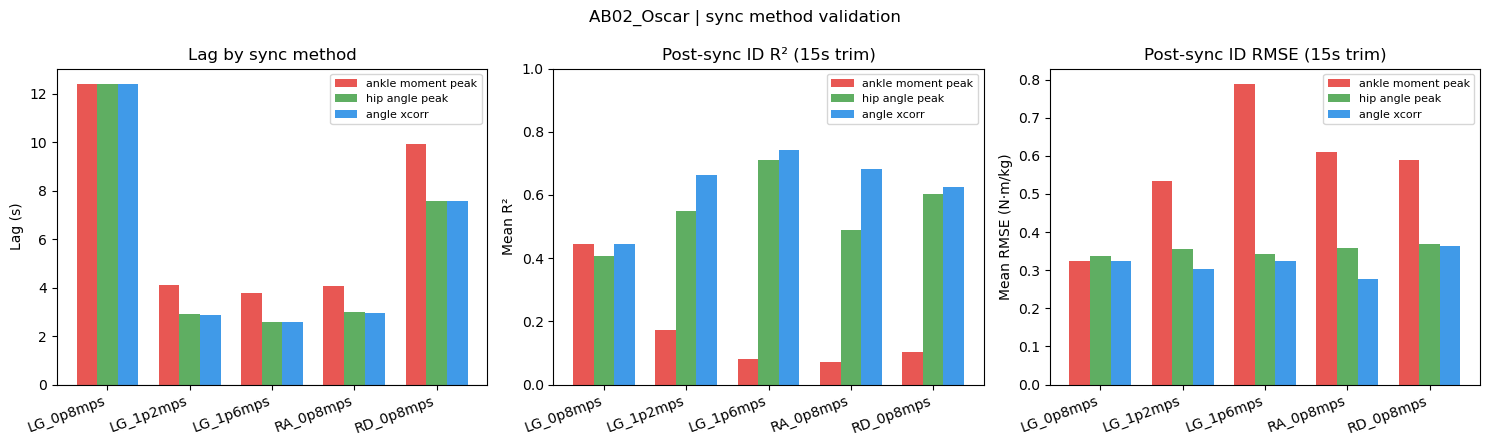

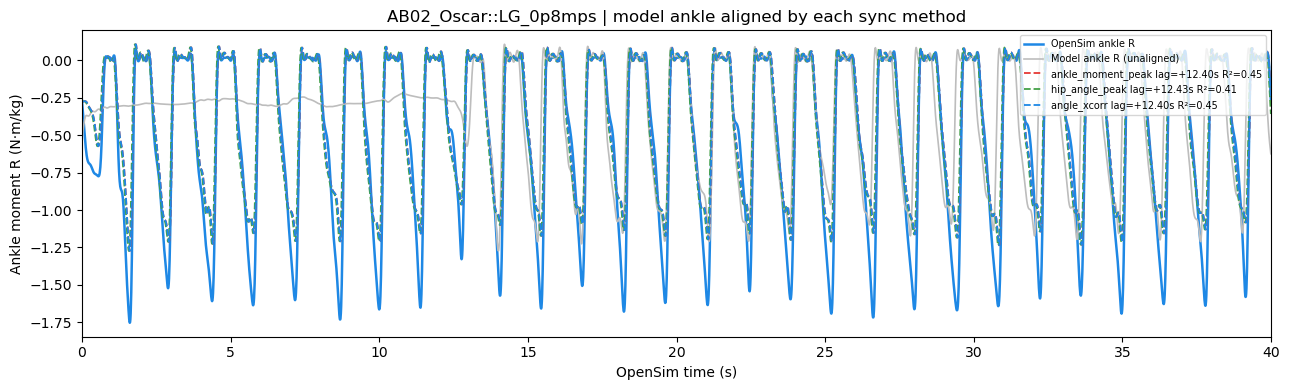

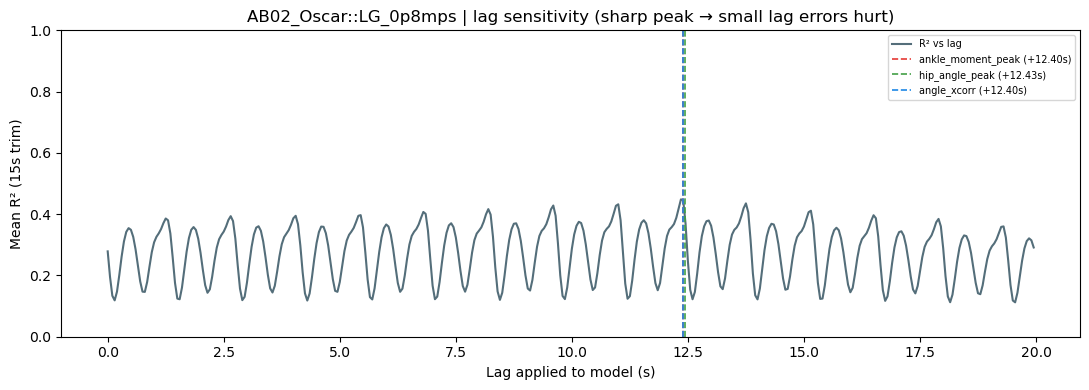

: 

In [ ]:
if compare_df.empty:
    raise RuntimeError('No comparison results — check Vicon IK paths.')

method_colors = {
    'ankle_moment_peak': '#e53935',
    'hip_angle_peak': '#43a047',
    'angle_xcorr': '#1e88e5',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
conditions = sorted(compare_df['condition'].unique())
x = np.arange(len(conditions))
width = 0.25

for i, method in enumerate(SYNC_METHODS):
    sub = compare_df[compare_df['method'] == method].set_index('condition')
    axes[0].bar(x + (i - 1) * width, [sub.loc[c, 'lag_seconds'] if c in sub.index else np.nan for c in conditions],
                width, label=method.replace('_', ' '), color=method_colors[method], alpha=0.85)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions, rotation=20, ha='right')
axes[0].set_ylabel('Lag (s)')
axes[0].set_title('Lag by sync method')
axes[0].legend(fontsize=8)

for i, method in enumerate(SYNC_METHODS):
    sub = compare_df[compare_df['method'] == method].set_index('condition')
    axes[1].bar(x + (i - 1) * width, [sub.loc[c, 'mean_r2_trim'] if c in sub.index else np.nan for c in conditions],
                width, label=method.replace('_', ' '), color=method_colors[method], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions, rotation=20, ha='right')
axes[1].set_ylabel('Mean R²')
axes[1].set_title(f'Post-sync ID R² ({TRANSIENT_TRIM_SEC:.0f}s trim)')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

for i, method in enumerate(SYNC_METHODS):
    sub = compare_df[compare_df['method'] == method].set_index('condition')
    axes[2].bar(x + (i - 1) * width, [sub.loc[c, 'mean_rmse_trim'] if c in sub.index else np.nan for c in conditions],
                width, label=method.replace('_', ' '), color=method_colors[method], alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(conditions, rotation=20, ha='right')
axes[2].set_ylabel('Mean RMSE (N·m/kg)')
axes[2].set_title(f'Post-sync ID RMSE ({TRANSIENT_TRIM_SEC:.0f}s trim)')
axes[2].legend(fontsize=8)

fig.suptitle(f'{SUBJECT} | sync method validation', fontsize=12)
fig.tight_layout()
plt.show()

# Overlay ankle moment for one trial: all three lags
demo_trial = sorted(SYNC_DATA)[0]
d = SYNC_DATA[demo_trial]
fs_hz = d['fs_hz']
peak_n = int(round(PEAK_PLOT_SEC * fs_hz))
t_id = d['t_id'] - d['t_id'][0]
t_imu = d['t_imu'] - d['t_imu'][0]

fig2, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_id[:peak_n], d['id_ankle_full'][:peak_n], color='#1e88e5', lw=1.8, label='OpenSim ankle R')
ax.plot(t_imu[:peak_n], d['pred_ankle_full'][:peak_n], color='#bdbdbd', lw=1.2, label='Model ankle R (unaligned)')

sub = compare_df[compare_df['trial'] == demo_trial]
for _, r in sub.iterrows():
    if not np.isfinite(r['lag_seconds']):
        continue
    lag = int(r['lag_samples'])
    sp = max(lag, 0)
    t_aligned = t_imu[sp:sp + peak_n] - r['lag_seconds']
    n = min(peak_n, len(d['pred_ankle_full']) - sp)
    ax.plot(
        t_aligned[:n], d['pred_ankle_full'][sp:sp + n],
        color=method_colors[r['method']], lw=1.3, ls='--',
        label=f"{r['method']} lag={r['lag_seconds']:+.2f}s R²={r['mean_r2_trim']:.2f}",
    )

ax.set_xlim(0, PEAK_PLOT_SEC)
ax.set_xlabel('OpenSim time (s)')
ax.set_ylabel('Ankle moment R (N·m/kg)')
ax.set_title(f'{demo_trial} | model ankle aligned by each sync method')
ax.legend(fontsize=7, loc='upper right')
fig2.tight_layout()
plt.show()

# Lag sensitivity: post-sync R² vs candidate lag (demo trial)
demo_sub = compare_df[compare_df['trial'] == demo_trial]
fs_demo = SYNC_DATA[demo_trial]['fs_hz']
pred_demo = SYNC_DATA[demo_trial]['pred_full']
id_demo = SYNC_DATA[demo_trial]['id_full']
max_lag = int(round(ALIGN_MAX_LAG_SEC * fs_demo))
lags = np.arange(0, min(int(20 * fs_demo), max_lag + 1), max(1, int(0.05 * fs_demo)))
r2_curve = [eval_id_at_lag(pred_demo, id_demo, int(l), fs_demo, trim_sec=TRANSIENT_TRIM_SEC)[1] for l in lags]

fig3, ax3 = plt.subplots(figsize=(11, 4))
ax3.plot(lags / fs_demo, r2_curve, color='#546e7a', lw=1.5, label='R² vs lag')
for _, r in demo_sub.iterrows():
    if not np.isfinite(r['lag_seconds']):
        continue
    ax3.axvline(r['lag_seconds'], color=method_colors[r['method']], ls='--', lw=1.2,
                label=f"{r['method']} ({r['lag_seconds']:+.2f}s)")
ax3.set_xlabel('Lag applied to model (s)')
ax3.set_ylabel(f'Mean R² ({TRANSIENT_TRIM_SEC:.0f}s trim)')
ax3.set_title(f'{demo_trial} | lag sensitivity (sharp peak → small lag errors hurt)')
ax3.set_ylim(0, 1)
ax3.legend(fontsize=7, loc='best')
fig3.tight_layout()
plt.show()

In [ ]:
if summary_df.empty:
    raise RuntimeError('No trials processed — check SUBJECT / paths.')

cohort = []
for subj_dir in sorted(IMU_IK_ROOT.glob('AB*')):
    if not subj_dir.is_dir() or subj_dir.name == SUBJECT:
        continue
    sub_manifest = list_subject_trials(subj_dir.name)
    for _, row in sub_manifest[sub_manifest['ready']].iterrows():
        try:
            imu = pickle.load(open(row['pkl_path'], 'rb'))
            pos_rad = np.deg2rad(build_model_input_from_pkl(imu))
            id_df = parse_opensim_table(row['id_path'])
            t_id = id_df.index.to_numpy(dtype=np.float64)
            fs_hz = 1.0 / float(np.median(np.diff(t_id))) if len(t_id) > 2 else DEFAULT_FS_HZ
            pos_f = lpf_mc(pos_rad, fs_hz, ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
            vel_f = lpf_mc(np.gradient(pos_f, 1.0 / fs_hz, axis=0), fs_hz, VEL_CUTOFF, FILTER_ORDER, IN_MODE)
            pred = lpf_mc(run_bilateral_inference(pos_f, vel_f), fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)
            id_nm = np.column_stack([
                id_df[c].to_numpy(dtype=np.float64) if c in id_df.columns else np.full(len(t_id), np.nan)
                for c in ID_COLS
            ])
            id_f = lpf_mc(id_nm / row['mass_kg'], fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)
            lag, _ = estimate_lag_from_moments(
                pred[:, ANKLE_MOMENT_IDX], id_f[:, ANKLE_MOMENT_IDX], fs_hz,
                int(round(ALIGN_MAX_LAG_SEC * fs_hz)), ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG,
            )
            cohort.append({'subject': subj_dir.name, 'lag_seconds': lag / fs_hz, 'lag_clipped': abs(lag) >= int(round(ALIGN_MAX_LAG_SEC * fs_hz))})
        except Exception:
            pass

cohort_df = pd.DataFrame(cohort)
print(f'Cohort reference (excluding {SUBJECT}): n={len(cohort_df)}')
if not cohort_df.empty:
    print(
        f"  lag median={cohort_df['lag_seconds'].median():+.2f}s | "
        f"p90={cohort_df['lag_seconds'].abs().quantile(0.9):.2f}s | "
        f"clipped={int(cohort_df['lag_clipped'].sum())}/{len(cohort_df)}"
    )

print(f'\n{SUBJECT} summary:')
print(
    f"  lag median={summary_df['lag_seconds'].median():+.2f}s | "
    f"clipped={int(summary_df['lag_clipped'].sum())}/{len(summary_df)} | "
    f"mean R²={summary_df['mean_r2'].mean():.3f}"
)

fig, ax = plt.subplots(figsize=(10, 4))
if not cohort_df.empty:
    ax.hist(cohort_df['lag_seconds'], bins=20, alpha=0.45, label='Other subjects', color='#90a4ae')
ax.scatter(summary_df['condition'], summary_df['lag_seconds'], color='#e53935', s=70, zorder=3, label=SUBJECT)
ax.axhline(0, color='gray', lw=0.8)
ax.axhline(ALIGN_MAX_LAG_SEC, color='gray', ls=':', lw=0.8)
ax.axhline(-ALIGN_MAX_LAG_SEC, color='gray', ls=':', lw=0.8)
ax.set_ylabel('Lag (s)  [pred_peak - id_peak]')
ax.set_xlabel('Condition')
ax.set_title(f'{SUBJECT} sync lag vs cohort')
ax.legend(loc='best')
fig.tight_layout()
plt.show()

In [ ]:
# --- Interactive explorer: angle xcorr sync (recommended method) ---
if not XCORR_SYNC_DATA:
    raise RuntimeError('Run cells 4–5 first to build XCORR_SYNC_DATA.')

names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']
trial_options = sorted(XCORR_SYNC_DATA)
trial_dd = widgets.Dropdown(options=trial_options, description='Trial:')
time_slider = widgets.FloatRangeSlider(description='Time (s):', continuous_update=False, layout=widgets.Layout(width='700px'))
peak_plot_sec = widgets.FloatSlider(description='Angle view (s):', min=10, max=120, step=1, value=PEAK_PLOT_SEC)
out = widgets.Output()


def _set_slider(trial_key):
    d = XCORR_SYNC_DATA[trial_key]
    t_rel = d['t_id'] - d['t_id'][0]
    t_sync = t_rel[d['start_id'] + d['trim_n']:d['start_id'] + d['n_sync']]
    time_slider.min, time_slider.max = float(t_sync[0]), float(t_sync[-1])
    time_slider.step = max((time_slider.max - time_slider.min) / 500, 1e-3)
    time_slider.value = (time_slider.min, time_slider.max)


def _plot_xcorr_sync_debug(trial_key, t_window, peak_sec):
    d = XCORR_SYNC_DATA[trial_key]
    fs_hz = d['fs_hz']
    lag = d['lag']
    trim_n = d['trim_n']
    pred_full, id_full = d['pred_full'], d['id_full']
    pred_sync, id_sync = d['pred_sync'], d['id_sync']

    preview_n = min(PREVIEW_FRAMES, len(pred_sync) - trim_n)
    preview_t = np.arange(trim_n, trim_n + preview_n) / fs_hz

    n_pre_pred = min(PREVIEW_FRAMES, len(pred_full))
    n_pre_id = min(PREVIEW_FRAMES, len(id_full))
    t_pre_pred = d['t_imu'][:n_pre_pred]
    t_pre_id = d['t_id'][:n_pre_id] - d['t_id'][0]
    t0, t1 = t_window
    t_sync_rel = (d['t_id'][d['start_id']:d['start_id'] + d['n_sync']] - d['t_id'][0])

    ankle_row = compare_df[(compare_df['trial'] == trial_key) & (compare_df['method'] == 'ankle_moment_peak')]
    ankle_r2 = float(ankle_row.iloc[0]['mean_r2_trim']) if len(ankle_row) else np.nan

    print(
        f"{trial_key} | angle_xcorr sync | lag={lag:+d} samples ({lag / fs_hz:+.3f}s) "
        f"clipped={d['lag_clipped']} | xcorr_score={d['xcorr_score']:.3f}\n"
        f"  ID metrics ({TRANSIENT_TRIM_SEC:.0f}s trim): RMSE={d['mean_rmse_trim']:.3f} "
        f"R²={d['mean_r2_trim']:.3f}  (ankle-peak R²={ankle_r2:.3f})"
    )
    display(xcorr_summary_df[xcorr_summary_df['trial'] == trial_key][[
        'condition', 'lag_seconds', 'xcorr_score', 'mean_r2_trim', 'mean_rmse_trim', 'n_eval_trim',
    ]])

    # --- Awinda vs Vicon hip flexion R (signals used for xcorr) ---
    peak_n = int(round(peak_sec * fs_hz))
    t_awinda = d['t_imu'][:peak_n] - d['t_imu'][0]
    t_vicon = d['t_id'][:peak_n] - d['t_id'][0]
    fig_angle, ax = plt.subplots(figsize=(13, 4))
    ax.plot(t_vicon, d['vicon_hip_deg'][:peak_n], label='Vicon hip R', color='#1e88e5', lw=1.8)
    ax.plot(t_awinda, d['awinda_hip_deg'][:peak_n], label='Awinda hip R', color='#43a047', lw=1.4)
    sp, sr = max(lag, 0), max(-lag, 0)
    n_show = min(peak_n, len(d['vicon_hip_deg']) - sr, len(d['awinda_hip_deg']) - sp)
    ax.plot(
        t_vicon[:n_show],
        d['awinda_hip_deg'][sp:sp + n_show],
        label=f'Awinda shifted by lag ({lag / fs_hz:+.2f}s)',
        color='#1e88e5', lw=1.2, ls='--', alpha=0.85,
    )
    ax.set_xlim(0, peak_sec)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Hip flexion R (deg)')
    ax.set_title(f'{trial_key} | Awinda vs Vicon hip angle (xcorr reference)')
    ax.legend(loc='upper right', fontsize=8)
    fig_angle.tight_layout()

    # --- pre/post sync all joints (ID) ---
    fig, axs = plt.subplots(6, 2, figsize=(14, 16), sharex='col')
    for c, name in enumerate(names):
        ax_pre, ax_post = axs[c]
        ax_pre.plot(t_pre_id, id_full[:n_pre_id, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax_pre.plot(t_pre_pred, pred_full[:n_pre_pred, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax_pre.set_ylabel('N·m/kg')
        ax_pre.set_title(f'{name} | pre-sync')
        ax_pre.set_xlim(0, PREVIEW_FRAMES / fs_hz)
        ax_pre.axhline(0, color='gray', lw=0.5, ls=':')
        if c == 0:
            ax_pre.legend(loc='upper right', fontsize=8)

        ax_post.plot(preview_t, id_sync[trim_n:trim_n + preview_n, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax_post.plot(preview_t, pred_sync[trim_n:trim_n + preview_n, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax_post.set_title(f'{name} | post-xcorr-sync (+{TRANSIENT_TRIM_SEC:.0f}s trim)')
        ax_post.set_xlim(preview_t[0], preview_t[-1] if len(preview_t) else PREVIEW_FRAMES / fs_hz)
        ax_post.axhline(0, color='gray', lw=0.5, ls=':')

    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time since sync (s)')
    fig.suptitle(f'{trial_key} | ID pre vs post xcorr sync', fontsize=12)
    fig.tight_layout()

    # --- synced ID explorer (slider on trimmed window) ---
    fig2, axs2 = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    pred_eval = pred_sync[trim_n:]
    id_eval = id_sync[trim_n:]
    t_eval = t_sync_rel[trim_n:]
    for c, ax in enumerate(axs2.reshape(-1)):
        rmse, r2 = rmse_r2(pred_eval[:, c], id_eval[:, c])
        ax.plot(t_eval, id_eval[:, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax.plot(t_eval, pred_eval[:, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{names[c]} | RMSE={rmse:.3f}, R²={r2:.3f}")
        ax.set_xlim(t0, t1)
        ax.set_ylabel('N·m/kg')
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        if c == 0:
            ax.legend()
    axs2[-1, 0].set_xlabel('Time (s)')
    axs2[-1, 1].set_xlabel('Time (s)')
    fig2.suptitle(
        f'{trial_key} | synced ID (xcorr lag={lag / fs_hz:+.2f}s, {TRANSIENT_TRIM_SEC:.0f}s trim)',
        fontsize=12,
    )
    fig2.tight_layout()

    return fig_angle, fig, fig2


def _redraw(*_):
    trial_key = trial_dd.value
    with out:
        out.clear_output(wait=True)
        fig_angle, fig, fig2 = _plot_xcorr_sync_debug(trial_key, time_slider.value, peak_plot_sec.value)
        plt.show(fig_angle)
        plt.show(fig)
        plt.show(fig2)


def _on_trial(change):
    _set_slider(change['new'])
    _redraw()

trial_dd.observe(_on_trial, names='value')
time_slider.observe(_redraw, names='value')
peak_plot_sec.observe(_redraw, names='value')
_set_slider(trial_dd.value)
display(widgets.VBox([
    widgets.HTML('<b>Single-trial debugger — angle xcorr sync (recommended)</b>'),
    widgets.HBox([trial_dd, peak_plot_sec]),
    time_slider,
    out,
]))
_redraw()